In [12]:
# CELL 1: CHECK COLAB GPU

import sys
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("✅ Colab GPU is ready.")
else:
    print("❌ GPU is unavailable.")
    print("Select Runtime → Change runtime type → T4 GPU.")

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4
✅ Colab GPU is ready.


In [14]:
# CELL 2: INSTALL REQUIRED PACKAGES

!apt-get update -qq
!apt-get install -y -qq ffmpeg

%pip install -q --upgrade \
    google-genai \
    openai-whisper \
    pydantic \
    pandas \
    numpy \
    rapidfuzz \
    jiwer \
    psutil \
    python-docx \
    reportlab \
    matplotlib \
    seaborn \
    streamlit

print("✅ Installation completed.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ Installation completed.


In [15]:
# CELL 3: CREATE PROJECT STRUCTURE

import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/AI_Meeting_Intelligence")
SRC_DIR = PROJECT_ROOT / "src"

folders = [
    SRC_DIR,
    PROJECT_ROOT / "data" / "audio",
    PROJECT_ROOT / "data" / "transcripts",
    PROJECT_ROOT / "data" / "gold_standard",
    PROJECT_ROOT / "outputs" / "transcriptions",
    PROJECT_ROOT / "outputs" / "generic",
    PROJECT_ROOT / "outputs" / "structured",
    PROJECT_ROOT / "outputs" / "evaluation",
    PROJECT_ROOT / "outputs" / "reports",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

# Allow Colab to import Python files from src.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("✅ Project created:", PROJECT_ROOT)
print("✅ Source folder added to Python path:", SRC_DIR)

print("\nFolders:")

for folder in folders:
    print("•", folder.relative_to(PROJECT_ROOT))

✅ Project created: /content/AI_Meeting_Intelligence
✅ Source folder added to Python path: /content/AI_Meeting_Intelligence/src

Folders:
• src
• data/audio
• data/transcripts
• data/gold_standard
• outputs/transcriptions
• outputs/generic
• outputs/structured
• outputs/evaluation
• outputs/reports


In [16]:
# CELL 3: CREATE PROJECT STRUCTURE

import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/AI_Meeting_Intelligence")
SRC_DIR = PROJECT_ROOT / "src"

folders = [
    SRC_DIR,
    PROJECT_ROOT / "data" / "audio",
    PROJECT_ROOT / "data" / "transcripts",
    PROJECT_ROOT / "data" / "gold_standard",
    PROJECT_ROOT / "outputs" / "transcriptions",
    PROJECT_ROOT / "outputs" / "generic",
    PROJECT_ROOT / "outputs" / "structured",
    PROJECT_ROOT / "outputs" / "evaluation",
    PROJECT_ROOT / "outputs" / "reports",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("✅ Project created:", PROJECT_ROOT)
print("✅ Source path activated:", SRC_DIR)

for folder in folders:
    print("📁", folder.relative_to(PROJECT_ROOT))

✅ Project created: /content/AI_Meeting_Intelligence
✅ Source path activated: /content/AI_Meeting_Intelligence/src
📁 src
📁 data/audio
📁 data/transcripts
📁 data/gold_standard
📁 outputs/transcriptions
📁 outputs/generic
📁 outputs/structured
📁 outputs/evaluation
📁 outputs/reports


In [17]:
# CELL 4: TEST GEMINI API

from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY was not found. "
        "Check Colab Secrets and enable Notebook access."
    )

client = genai.Client(api_key=GEMINI_API_KEY)

preferred_models = [
    "gemini-3-flash-preview",
    "gemini-2.5-flash",
    "gemini-2.0-flash-001",
]

SELECTED_MODEL = None
last_error = None

for candidate in preferred_models:
    try:
        response = client.models.generate_content(
            model=candidate,
            contents=(
                "Reply with exactly: "
                "Gemini connection successful"
            )
        )

        if response.text:
            SELECTED_MODEL = candidate
            print("✅ API key accepted.")
            print("✅ Selected model:", SELECTED_MODEL)
            print("✅ Response:", response.text.strip())
            break

    except Exception as error:
        last_error = error
        print(f"Model unavailable: {candidate}")

if SELECTED_MODEL is None:
    print("\n❌ GEMINI CONNECTION FAILED")
    print("Error type:", type(last_error).__name__)
    print("Error details:", str(last_error))
    raise RuntimeError(
        "No tested Gemini model was accessible."
    )

✅ API key accepted.
✅ Selected model: gemini-3-flash-preview
✅ Response: Gemini connection successful


In [18]:
# CELL 5: CREATE PYDANTIC SCHEMA

schema_code = '''
from typing import List, Optional, Literal
from pydantic import BaseModel, Field, ConfigDict


class Decision(BaseModel):
    model_config = ConfigDict(extra="forbid")

    decision: str
    evidence: str
    confidence: float = Field(ge=0.0, le=1.0)


class ActionItem(BaseModel):
    model_config = ConfigDict(extra="forbid")

    action: str
    owner: Optional[str] = None
    deadline: Optional[str] = None

    status: Literal[
        "assigned",
        "proposed",
        "unclear"
    ]

    evidence: str
    confidence: float = Field(ge=0.0, le=1.0)


class MeetingIntelligence(BaseModel):
    model_config = ConfigDict(extra="forbid")

    meeting_title: str
    summary: str
    key_topics: List[str] = Field(default_factory=list)
    decisions: List[Decision] = Field(default_factory=list)
    action_items: List[ActionItem] = Field(default_factory=list)
    unresolved_issues: List[str] = Field(default_factory=list)
    ambiguities: List[str] = Field(default_factory=list)
'''

schema_file = SRC_DIR / "schema.py"
schema_file.write_text(schema_code, encoding="utf-8")

print("✅ Schema created:", schema_file)

✅ Schema created: /content/AI_Meeting_Intelligence/src/schema.py


In [19]:
# CELL 7: CREATE TRANSCRIPT PROCESSOR

core_code = '''
import re


def clean_transcript(text: str) -> str:
    if not isinstance(text, str):
        raise TypeError("Transcript must be text.")

    text = text.replace("\\\\r\\\\n", "\\\\n")
    text = text.replace("\\\\r", "\\\\n")
    text = text.replace("\\\\u00a0", " ")

    cleaned_lines = []

    for line in text.split("\\\\n"):
        line = re.sub(r"[ \\\\t]+", " ", line).strip()

        if line:
            cleaned_lines.append(line)

    cleaned = "\\\\n".join(cleaned_lines).strip()

    if not cleaned:
        raise ValueError("Transcript is empty.")

    return cleaned


def transcript_statistics(text: str) -> dict:
    cleaned = clean_transcript(text)
    words = cleaned.split()

    speaker_turns = sum(
        1
        for line in cleaned.splitlines()
        if re.match(
            r"^[A-Za-z][A-Za-z .'-]{0,40}:",
            line
        )
    )

    return {
        "characters": len(cleaned),
        "words": len(words),
        "lines": len(cleaned.splitlines()),
        "speaker_turns": speaker_turns,
        "estimated_minutes": round(
            len(words) / 130,
            2
        )
    }
'''

core_file = SRC_DIR / "core.py"
core_file.write_text(core_code, encoding="utf-8")

print("✅ Transcript processor created:", core_file)

✅ Transcript processor created: /content/AI_Meeting_Intelligence/src/core.py


In [20]:
# CELL 8: TEST TRANSCRIPT PROCESSING

import importlib
import core

importlib.reload(core)

from core import clean_transcript, transcript_statistics

raw_transcript = """
Project Review Meeting

Aisha: The current launch date is 18 September.

Bilal: I think we should delay it, but I am not certain.

Aisha: No, we have agreed to retain 18 September.

Manager: Bilal, please complete the security test by Friday.

Bilal: Yes, I will complete it by Friday.

Sara: Should I prepare the customer email?

Manager: Let us discuss that tomorrow. It is not assigned yet.
"""

evaluation_transcript = clean_transcript(raw_transcript)

transcript_file = (
    PROJECT_ROOT
    / "data"
    / "transcripts"
    / "controlled_meeting_001.txt"
)

transcript_file.write_text(
    evaluation_transcript,
    encoding="utf-8"
)

statistics = transcript_statistics(evaluation_transcript)

print("✅ Transcript cleaned and saved.")
print("✅ Saved to:", transcript_file)

print("\nTRANSCRIPT:\n")
print(evaluation_transcript)

print("\nSTATISTICS:")
for key, value in statistics.items():
    print(f"{key}: {value}")

✅ Transcript cleaned and saved.
✅ Saved to: /content/AI_Meeting_Intelligence/data/transcripts/controlled_meeting_001.txt

TRANSCRIPT:

Projec Review Mee ing

Aisha: The curren launch da e is 18 Sep ember.

Bilal: I hink we should delay i , bu I am no cer ain.

Aisha: No, we have agreed o re ain 18 Sep ember.

Manager: Bilal, please comple e he securi y es by Friday.

Bilal: Yes, I will comple e i by Friday.

Sara: Should I prepare he cus omer email?

Manager: Le us discuss ha omorrow. I is no assigned ye .

STATISTICS:
characters: 376
words: 79
lines: 15
speaker_turns: 7
estimated_minutes: 0.61


In [21]:
# CELL 9: CREATE WHISPER TRANSCRIPTION MODULE

transcription_code = '''
import json
import time
from pathlib import Path

import torch
import whisper


_whisper_models = {}


def get_whisper_model(model_name="small.en"):
    if model_name not in _whisper_models:
        device = (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        _whisper_models[model_name] = whisper.load_model(
            model_name,
            device=device
        )

    return _whisper_models[model_name]


def transcribe_audio(
    audio_path,
    output_directory,
    model_name="small.en"
):
    audio_path = Path(audio_path)
    output_directory = Path(output_directory)

    if not audio_path.exists():
        raise FileNotFoundError(
            f"Audio not found: {audio_path}"
        )

    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model = get_whisper_model(model_name)

    start_time = time.perf_counter()

    result = model.transcribe(
        str(audio_path),
        language="en",
        task="transcribe",
        temperature=0.0,
        fp16=(device == "cuda"),
        verbose=False
    )

    processing_time = (
        time.perf_counter() - start_time
    )

    transcript = result.get("text", "").strip()

    if not transcript:
        raise RuntimeError(
            "Whisper returned an empty transcript."
        )

    output = {
        "source_file": audio_path.name,
        "whisper_model": model_name,
        "device": device,
        "language": result.get("language", "en"),
        "processing_seconds": round(
            processing_time,
            3
        ),
        "transcript": transcript
    }

    output_file = (
        output_directory
        / f"{audio_path.stem}_transcription.json"
    )

    output_file.write_text(
        json.dumps(
            output,
            indent=2,
            ensure_ascii=False
        ),
        encoding="utf-8"
    )

    output["output_file"] = str(output_file)

    return output
'''

transcription_file = SRC_DIR / "transcription.py"

transcription_file.write_text(
    transcription_code,
    encoding="utf-8"
)

print("✅ Whisper module created:", transcription_file)

✅ Whisper module created: /content/AI_Meeting_Intelligence/src/transcription.py


In [23]:
# CELL 10: UPLOAD AUDIO

from google.colab import files
from pathlib import Path

uploaded = files.upload()

if not uploaded:
    raise ValueError("No audio file was selected.")

uploaded_name = next(iter(uploaded))

audio_path = (
    PROJECT_ROOT
    / "data"
    / "audio"
    / uploaded_name
)

audio_path.write_bytes(uploaded[uploaded_name])

print("✅ Audio uploaded:", audio_path)

Saving AUDIO-2026-01-16-04-29-26.m4a to AUDIO-2026-01-16-04-29-26.m4a
✅ Audio uploaded: /content/AI_Meeting_Intelligence/data/audio/AUDIO-2026-01-16-04-29-26.m4a


In [24]:
# CELL 11: TRANSCRIBE REAL AUDIO

import importlib
import transcription

importlib.reload(transcription)

from transcription import transcribe_audio

whisper_result = transcribe_audio(
    audio_path=audio_path,
    output_directory=(
        PROJECT_ROOT
        / "outputs"
        / "transcriptions"
    ),
    model_name="small.en"
)

print("✅ REAL WHISPER TRANSCRIPTION COMPLETED")
print("Model:", whisper_result["whisper_model"])
print("Device:", whisper_result["device"])
print(
    "Processing time:",
    whisper_result["processing_seconds"],
    "seconds"
)

print("\nTRANSCRIPT:\n")
print(whisper_result["transcript"])

100%|███████████████████████████████████████| 461M/461M [00:05<00:00, 91.1MiB/s]
100%|██████████| 3750/3750 [00:05<00:00, 748.46frames/s]

✅ REAL WHISPER TRANSCRIPTION COMPLETED
Model: small.en
Device: cuda
Processing time: 5.96 seconds

TRANSCRIPT:

I'm going to go to the infographic. I'm going to go to the next slide. I'm going to show you a different kind of picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture. I'm going to show you the picture.


In [25]:
# CELL 12: CREATE GEMINI EXTRACTION MODULE

llm_code = '''
import json
import time
from pathlib import Path

from google import genai
from google.genai import types

from schema import MeetingIntelligence


GENERIC_PROMPT = """
Analyse the following meeting transcript.

Identify its summary, topics, decisions, action items,
owners, deadlines, unresolved issues and ambiguities.

Use only information from the transcript.

TRANSCRIPT:
{transcript}
"""


STRUCTURED_PROMPT = """
You are a context-aware meeting intelligence system.

Extract information only from the supplied transcript.

Rules:

1. A decision must be a confirmed outcome.
2. Do not classify suggestions, rejected proposals,
   opinions or possibilities as confirmed decisions.
3. An assigned action must have been explicitly assigned
   or accepted.
4. Use status "proposed" when a task was only suggested.
5. Use status "unclear" when assignment is ambiguous.
6. Use null when an owner or deadline is not stated.
7. Evidence must be an exact quotation from the transcript.
8. Never invent decisions, tasks, owners or deadlines.
9. Put unanswered matters under unresolved_issues.
10. Put uncertain interpretations under ambiguities.
11. Return an empty list when no supported item exists.

TRANSCRIPT:
{transcript}
"""


def extract_meeting(
    transcript,
    api_key,
    model_name,
    prompt_type,
    output_directory,
    run_number=1,
    temperature=0.2
):
    if prompt_type not in {
        "generic",
        "structured"
    }:
        raise ValueError(
            "Prompt type must be generic or structured."
        )

    transcript = transcript.strip()

    if not transcript:
        raise ValueError("Transcript is empty.")

    prompt_template = (
        GENERIC_PROMPT
        if prompt_type == "generic"
        else STRUCTURED_PROMPT
    )

    prompt = prompt_template.format(
        transcript=transcript
    )

    client = genai.Client(api_key=api_key)

    start_time = time.perf_counter()

    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=temperature,
            response_mime_type="application/json",
            response_schema=MeetingIntelligence
        )
    )

    processing_time = (
        time.perf_counter() - start_time
    )

    if response.parsed is not None:
        if isinstance(
            response.parsed,
            MeetingIntelligence
        ):
            validated = response.parsed
        else:
            validated = MeetingIntelligence.model_validate(
                response.parsed
            )
    else:
        validated = (
            MeetingIntelligence.model_validate_json(
                response.text
            )
        )

    record = {
        "model": model_name,
        "prompt_type": prompt_type,
        "temperature": temperature,
        "run_number": run_number,
        "processing_seconds": round(
            processing_time,
            3
        ),
        "schema_valid": True,
        "result": validated.model_dump()
    }

    output_directory = Path(output_directory)

    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    output_file = output_directory / (
        f"{prompt_type}_run_{run_number}.json"
    )

    output_file.write_text(
        json.dumps(
            record,
            indent=2,
            ensure_ascii=False
        ),
        encoding="utf-8"
    )

    record["output_file"] = str(output_file)

    return record
'''

llm_file = SRC_DIR / "llm_extraction.py"
llm_file.write_text(llm_code, encoding="utf-8")

print("✅ Gemini extraction module created:", llm_file)

✅ Gemini extraction module created: /content/AI_Meeting_Intelligence/src/llm_extraction.py


In [26]:
# CELL 14: CREATE REPORT EXPORT MODULE

export_code = '''
import json
from html import escape
from pathlib import Path

from docx import Document
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak
)


def create_markdown(result):
    lines = [
        f"# {result['meeting_title']}",
        "",
        "## Summary",
        "",
        result["summary"],
        "",
        "## Key Topics",
        ""
    ]

    if result["key_topics"]:
        for topic in result["key_topics"]:
            lines.append(f"- {topic}")
    else:
        lines.append("- None identified")

    lines.extend(["", "## Decisions", ""])

    if result["decisions"]:
        for number, decision in enumerate(
            result["decisions"],
            start=1
        ):
            lines.extend([
                f"### Decision {number}",
                "",
                decision["decision"],
                "",
                f"**Evidence:** {decision['evidence']}",
                "",
                f"**Confidence:** {decision['confidence']}",
                ""
            ])
    else:
        lines.append("No confirmed decisions identified.")

    lines.extend(["", "## Action Items", ""])

    if result["action_items"]:
        for number, action in enumerate(
            result["action_items"],
            start=1
        ):
            lines.extend([
                f"### Action {number}",
                "",
                f"**Task:** {action['action']}",
                "",
                f"**Owner:** {action.get('owner') or 'Not stated'}",
                "",
                f"**Deadline:** {action.get('deadline') or 'Not stated'}",
                "",
                f"**Status:** {action['status']}",
                "",
                f"**Evidence:** {action['evidence']}",
                "",
                f"**Confidence:** {action['confidence']}",
                ""
            ])
    else:
        lines.append("No action items identified.")

    lines.extend(["", "## Unresolved Issues", ""])

    if result["unresolved_issues"]:
        for item in result["unresolved_issues"]:
            lines.append(f"- {item}")
    else:
        lines.append("- None identified")

    lines.extend(["", "## Ambiguities", ""])

    if result["ambiguities"]:
        for item in result["ambiguities"]:
            lines.append(f"- {item}")
    else:
        lines.append("- None identified")

    lines.extend([
        "",
        "---",
        "",
        "AI-generated draft. Human review is required."
    ])

    return "\\n".join(lines)


def export_reports(result, transcript, output_directory):
    output_directory = Path(output_directory)

    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    json_path = output_directory / "meeting_report.json"
    markdown_path = output_directory / "meeting_report.md"
    docx_path = output_directory / "meeting_report.docx"
    pdf_path = output_directory / "meeting_report.pdf"

    json_path.write_text(
        json.dumps(
            result,
            indent=2,
            ensure_ascii=False
        ),
        encoding="utf-8"
    )

    markdown = create_markdown(result)

    markdown_path.write_text(
        markdown,
        encoding="utf-8"
    )

    document = Document()
    document.add_heading(
        result["meeting_title"],
        level=0
    )

    document.add_paragraph(
        "AI-generated draft — human review required."
    )

    document.add_heading("Summary", level=1)
    document.add_paragraph(result["summary"])

    document.add_heading("Key Topics", level=1)

    for topic in result["key_topics"]:
        document.add_paragraph(
            topic,
            style="List Bullet"
        )

    document.add_heading("Decisions", level=1)

    if not result["decisions"]:
        document.add_paragraph(
            "No confirmed decisions identified."
        )

    for decision in result["decisions"]:
        document.add_paragraph(
            decision["decision"],
            style="List Bullet"
        )
        document.add_paragraph(
            f"Evidence: {decision['evidence']}"
        )

    document.add_heading("Action Items", level=1)

    if not result["action_items"]:
        document.add_paragraph(
            "No action items identified."
        )

    for action in result["action_items"]:
        document.add_paragraph(
            action["action"],
            style="List Bullet"
        )
        document.add_paragraph(
            f"Owner: {action.get('owner') or 'Not stated'}"
        )
        document.add_paragraph(
            f"Deadline: {action.get('deadline') or 'Not stated'}"
        )
        document.add_paragraph(
            f"Status: {action['status']}"
        )
        document.add_paragraph(
            f"Evidence: {action['evidence']}"
        )

    document.add_heading("Original Transcript", level=1)
    document.add_paragraph(transcript)

    document.save(docx_path)

    font_path = (
        "/usr/share/fonts/truetype/"
        "dejavu/DejaVuSans.ttf"
    )

    pdfmetrics.registerFont(
        TTFont("DejaVu", font_path)
    )

    styles = getSampleStyleSheet()

    for style_name in [
        "Title",
        "Heading1",
        "Heading2",
        "BodyText"
    ]:
        styles[style_name].fontName = "DejaVu"

    pdf = SimpleDocTemplate(
        str(pdf_path),
        pagesize=A4,
        rightMargin=50,
        leftMargin=50,
        topMargin=50,
        bottomMargin=50
    )

    story = [
        Paragraph(
            escape(result["meeting_title"]),
            styles["Title"]
        ),
        Spacer(1, 12),
        Paragraph(
            "AI-generated draft — human review required.",
            styles["BodyText"]
        ),
        Spacer(1, 14),
        Paragraph("Summary", styles["Heading1"]),
        Paragraph(
            escape(result["summary"]),
            styles["BodyText"]
        ),
        Spacer(1, 12),
        Paragraph("Decisions", styles["Heading1"])
    ]

    if not result["decisions"]:
        story.append(
            Paragraph(
                "No confirmed decisions identified.",
                styles["BodyText"]
            )
        )

    for decision in result["decisions"]:
        story.append(
            Paragraph(
                escape(decision["decision"]),
                styles["BodyText"]
            )
        )
        story.append(
            Paragraph(
                "Evidence: "
                + escape(decision["evidence"]),
                styles["BodyText"]
            )
        )
        story.append(Spacer(1, 8))

    story.append(
        Paragraph("Action Items", styles["Heading1"])
    )

    if not result["action_items"]:
        story.append(
            Paragraph(
                "No action items identified.",
                styles["BodyText"]
            )
        )

    for action in result["action_items"]:
        action_text = (
            f"Task: {action['action']}<br/>"
            f"Owner: {action.get('owner') or 'Not stated'}<br/>"
            f"Deadline: {action.get('deadline') or 'Not stated'}<br/>"
            f"Status: {action['status']}<br/>"
            f"Evidence: {action['evidence']}"
        )

        story.append(
            Paragraph(
                escape(action_text).replace(
                    "&lt;br/&gt;",
                    "<br/>"
                ),
                styles["BodyText"]
            )
        )
        story.append(Spacer(1, 8))

    story.extend([
        PageBreak(),
        Paragraph(
            "Original Transcript",
            styles["Heading1"]
        ),
        Paragraph(
            escape(transcript).replace(
                "\\n",
                "<br/>"
            ),
            styles["BodyText"]
        )
    ])

    pdf.build(story)

    return {
        "json": str(json_path),
        "markdown": str(markdown_path),
        "docx": str(docx_path),
        "pdf": str(pdf_path)
    }
'''

export_file = SRC_DIR / "report_export.py"

export_file.write_text(
    export_code,
    encoding="utf-8"
)

print("✅ Report-export module created:", export_file)

✅ Report-export module created: /content/AI_Meeting_Intelligence/src/report_export.py


In [30]:
# REPLACEMENT CELL 5: GEMINI-COMPATIBLE PYDANTIC SCHEMA

schema_code = '''
from typing import List, Optional, Literal
from pydantic import BaseModel, Field


class Decision(BaseModel):
    decision: str = Field(
        description="A confirmed meeting decision."
    )

    evidence: str = Field(
        description="Exact quotation supporting the decision."
    )

    confidence: float = Field(
        ge=0.0,
        le=1.0
    )


class ActionItem(BaseModel):
    action: str = Field(
        description="A meeting task or follow-up action."
    )

    owner: Optional[str] = Field(
        default=None,
        description="Responsible person or null."
    )

    deadline: Optional[str] = Field(
        default=None,
        description="Stated deadline or null."
    )

    status: Literal[
        "assigned",
        "proposed",
        "unclear"
    ]

    evidence: str = Field(
        description="Exact supporting quotation."
    )

    confidence: float = Field(
        ge=0.0,
        le=1.0
    )


class MeetingIntelligence(BaseModel):
    meeting_title: str
    summary: str

    key_topics: List[str] = Field(
        default_factory=list
    )

    decisions: List[Decision] = Field(
        default_factory=list
    )

    action_items: List[ActionItem] = Field(
        default_factory=list
    )

    unresolved_issues: List[str] = Field(
        default_factory=list
    )

    ambiguities: List[str] = Field(
        default_factory=list
    )
'''

schema_file = SRC_DIR / "schema.py"

schema_file.write_text(
    schema_code,
    encoding="utf-8"
)

print("✅ Gemini-compatible schema saved.")

✅ Gemini-compatible schema saved.


In [31]:
# CLEAR OLD SCHEMA AND EXTRACTION MODULES

import sys
import importlib

for module_name in [
    "schema",
    "llm_extraction"
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

import schema
import llm_extraction

importlib.reload(schema)
importlib.reload(llm_extraction)

from schema import MeetingIntelligence
from llm_extraction import extract_meeting

print("✅ Updated schema and extraction module loaded.")

✅ Updated schema and extraction module loaded.


In [32]:
# REPLACEMENT CELL 13: REAL STRUCTURED GEMINI EXTRACTION

import sys
import json
import importlib
from pathlib import Path

from google.colab import userdata
from google import genai

PROJECT_ROOT = Path("/content/AI_Meeting_Intelligence")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Reload the corrected schema and extraction module.
for module_name in ["schema", "llm_extraction"]:
    if module_name in sys.modules:
        del sys.modules[module_name]

import schema
import llm_extraction

from llm_extraction import extract_meeting

print("✅ Corrected modules loaded.")

# Restore Gemini API key.
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY was not found. "
        "Open Colab Secrets and enable Notebook access."
    )

# Find an accessible Gemini model.
client = genai.Client(api_key=GEMINI_API_KEY)

candidate_models = [
    "gemini-3-flash-preview",
    "gemini-2.5-flash",
    "gemini-2.0-flash-001"
]

SELECTED_MODEL = None
model_errors = []

for candidate in candidate_models:
    try:
        test_response = client.models.generate_content(
            model=candidate,
            contents="Reply with exactly: OK"
        )

        if test_response.text:
            SELECTED_MODEL = candidate
            print("✅ Selected model:", SELECTED_MODEL)
            break

    except Exception as error:
        model_errors.append(
            f"{candidate}: {type(error).__name__}"
        )

if SELECTED_MODEL is None:
    print("\n".join(model_errors))

    raise RuntimeError(
        "No Gemini model is accessible. "
        "Check the API key and rerun Cell 4."
    )

# Find the saved real Whisper transcription.
transcription_directory = (
    PROJECT_ROOT
    / "outputs"
    / "transcriptions"
)

transcription_files = sorted(
    transcription_directory.glob(
        "*_transcription.json"
    )
)

if not transcription_files:
    raise FileNotFoundError(
        "No Whisper transcription was found. "
        "Rerun the audio upload and transcription cells."
    )

transcription_file = transcription_files[-1]

transcription_record = json.loads(
    transcription_file.read_text(
        encoding="utf-8"
    )
)

real_transcript = transcription_record.get(
    "transcript",
    ""
).strip()

if not real_transcript:
    raise ValueError(
        "The saved Whisper transcript is empty."
    )

print("✅ Whisper transcript loaded.")
print("Transcript words:", len(real_transcript.split()))

# Run actual structured Gemini extraction.
structured_result = extract_meeting(
    transcript=real_transcript,
    api_key=GEMINI_API_KEY,
    model_name=SELECTED_MODEL,
    prompt_type="structured",
    output_directory=(
        PROJECT_ROOT
        / "outputs"
        / "structured"
    ),
    run_number=1,
    temperature=0.2
)

print("\n✅ REAL STRUCTURED EXTRACTION COMPLETED")
print("✅ Whisper audio transcription used")
print("✅ Gemini extraction completed")
print("✅ Pydantic schema validation passed")
print("✅ Model:", structured_result["model"])
print("✅ Saved to:", structured_result["output_file"])

print("\nSTRUCTURED RESULT:\n")

print(
    json.dumps(
        structured_result["result"],
        indent=2,
        ensure_ascii=False
    )
)

✅ Corrected modules loaded.
✅ Selected model: gemini-3-flash-preview
✅ Whisper transcript loaded.
Transcript words: 123

✅ REAL STRUCTURED EXTRACTION COMPLETED
✅ Whisper audio transcription used
✅ Gemini extraction completed
✅ Pydantic schema validation passed
✅ Model: gemini-3-flash-preview
✅ Saved to: /content/AI_Meeting_Intelligence/outputs/structured/structured_run_1.json

STRUCTURED RESULT:

{
  "meeting_title": "Infographic Presentation",
  "summary": "The speaker repeatedly announces their intention to transition to a new slide to display an infographic and a specific picture.",
  "key_topics": [
    "Infographic presentation",
    "Visual aids"
  ],
  "decisions": [],
  "action_items": [],
  "unresolved_issues": [],
  "ambiguities": [
    "The repetitive phrasing suggests a possible technical delay or difficulty in displaying the intended visual content."
  ]
}


In [34]:
# FIX MISSING PDF FONT

!apt-get update -qq
!apt-get install -y -qq fonts-dejavu-core

from pathlib import Path

font_path = Path(
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
)

print("Font exists:", font_path.exists())
print("Font path:", font_path)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Font exists: True
Font path: /usr/share/fonts/truetype/dejavu/DejaVuSans.ttf


In [35]:
# CELL 16: DOWNLOAD REPORTS AS ZIP

import shutil
from google.colab import files

reports_folder = (
    PROJECT_ROOT
    / "outputs"
    / "reports"
)

zip_base = "/content/AI_Meeting_Intelligence_Reports"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    reports_folder
)

print("✅ Reports ZIP created:", zip_path)

files.download(zip_path)

✅ Reports ZIP created: /content/AI_Meeting_Intelligence_Reports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# CELL 17: GENERATE ACTUAL SYSTEM GRAPHS

import json
import matplotlib.pyplot as plt
from pathlib import Path

graphs_directory = (
    PROJECT_ROOT
    / "outputs"
    / "evaluation"
    / "graphs"
)

graphs_directory.mkdir(
    parents=True,
    exist_ok=True
)

# Load actual Whisper result.
transcription_files = sorted(
    (
        PROJECT_ROOT
        / "outputs"
        / "transcriptions"
    ).glob("*_transcription.json")
)

if not transcription_files:
    raise FileNotFoundError(
        "No Whisper transcription result was found."
    )

whisper_data = json.loads(
    transcription_files[-1].read_text(
        encoding="utf-8"
    )
)

# Load actual Gemini result.
structured_file = (
    PROJECT_ROOT
    / "outputs"
    / "structured"
    / "structured_run_1.json"
)

if not structured_file.exists():
    raise FileNotFoundError(
        "No structured Gemini result was found."
    )

gemini_data = json.loads(
    structured_file.read_text(
        encoding="utf-8"
    )
)

result = gemini_data["result"]

plt.style.use("seaborn-v0_8-whitegrid")

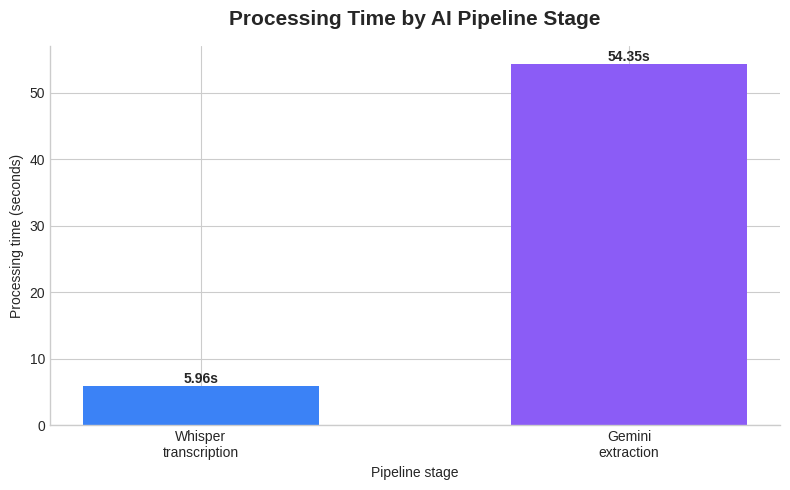

✅ Saved: /content/AI_Meeting_Intelligence/outputs/evaluation/graphs/figure_processing_time.png


In [38]:
# CELL 18: PROCESSING-TIME GRAPH

stages = [
    "Whisper\ntranscription",
    "Gemini\nextraction"
]

processing_times = [
    whisper_data["processing_seconds"],
    gemini_data["processing_seconds"]
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    stages,
    processing_times,
    color=["#3B82F6", "#8B5CF6"],
    width=0.55
)

ax.set_title(
    "Processing Time by AI Pipeline Stage",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Processing time (seconds)")
ax.set_xlabel("Pipeline stage")

for bar, value in zip(bars, processing_times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}s",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

processing_graph_path = (
    graphs_directory
    / "figure_processing_time.png"
)

fig.savefig(
    processing_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", processing_graph_path)

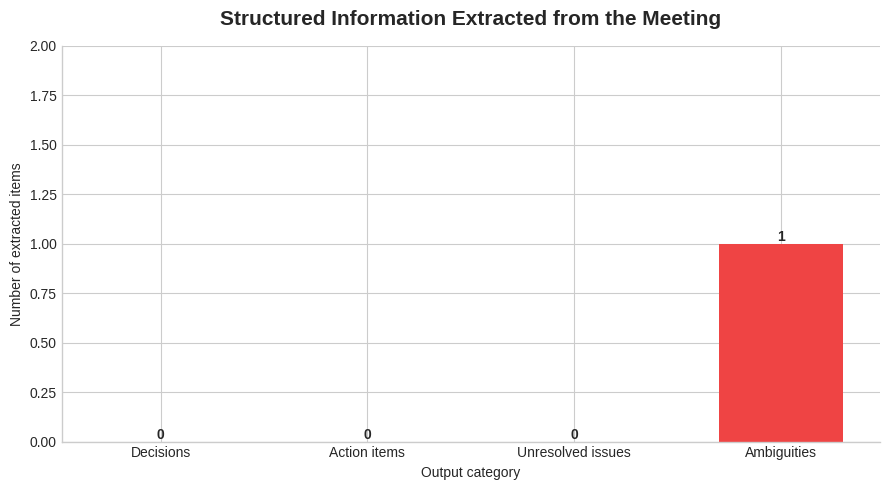

✅ Saved: /content/AI_Meeting_Intelligence/outputs/evaluation/graphs/figure_extracted_categories.png


In [39]:
# CELL 19: EXTRACTED-ITEM GRAPH

categories = [
    "Decisions",
    "Action items",
    "Unresolved issues",
    "Ambiguities"
]

counts = [
    len(result.get("decisions", [])),
    len(result.get("action_items", [])),
    len(result.get("unresolved_issues", [])),
    len(result.get("ambiguities", []))
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    categories,
    counts,
    color=[
        "#10B981",
        "#3B82F6",
        "#F59E0B",
        "#EF4444"
    ],
    width=0.6
)

ax.set_title(
    "Structured Information Extracted from the Meeting",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Number of extracted items")
ax.set_xlabel("Output category")
ax.set_ylim(
    0,
    max(counts + [1]) + 1
)

for bar, value in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

extraction_graph_path = (
    graphs_directory
    / "figure_extracted_categories.png"
)

fig.savefig(
    extraction_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved:", extraction_graph_path)

In [40]:
# CELL 20: CREATE GITHUB SUPPORT FILES

from pathlib import Path

PROJECT_ROOT = Path("/content/AI_Meeting_Intelligence")

requirements_text = """
google-genai
openai-whisper
pydantic
streamlit
pandas==2.2.3
numpy
rapidfuzz
jiwer
psutil
python-docx
reportlab
matplotlib
seaborn
torch
""".strip()

(PROJECT_ROOT / "requirements.txt").write_text(
    requirements_text + "\n",
    encoding="utf-8"
)

packages_text = """
ffmpeg
fonts-dejavu-core
""".strip()

(PROJECT_ROOT / "packages.txt").write_text(
    packages_text + "\n",
    encoding="utf-8"
)

gitignore_text = """
__pycache__/
*.pyc
.env
.streamlit/secrets.toml
.ipynb_checkpoints/
.DS_Store
*.log
""".strip()

(PROJECT_ROOT / ".gitignore").write_text(
    gitignore_text + "\n",
    encoding="utf-8"
)

readme_text = """
# AI Meeting Intelligence System

An end-to-end meeting-intelligence system that converts meeting
audio or transcripts into structured, reviewable outputs.

## Implemented Pipeline

1. Audio or transcript input
2. Whisper speech transcription
3. Transcript cleaning
4. Gemini-based contextual extraction
5. Pydantic schema validation
6. Decisions and action-item presentation
7. JSON, Markdown, Word and PDF report export
8. Performance and extraction visualisations

## Extracted Information

- Meeting summary
- Key topics
- Confirmed decisions
- Action items
- Owners
- Deadlines
- Supporting evidence
- Unresolved issues
- Ambiguities

## Privacy

API keys are not stored in this repository. Configure the
`GEMINI_API_KEY` as a secure environment variable or Streamlit secret.

## Human Review

All AI-generated meeting records are drafts and must be checked
against the original transcript before professional use.

## Current Model Configuration

- Speech recognition: Whisper `small.en`
- Language model: Gemini Flash model selected according to API access
- Structured validation: Pydantic
- Interface: Streamlit
""".strip()

(PROJECT_ROOT / "README.md").write_text(
    readme_text + "\n",
    encoding="utf-8"
)

# Make src a Python package.
(PROJECT_ROOT / "src" / "__init__.py").touch()

print("✅ requirements.txt created")
print("✅ packages.txt created")
print("✅ .gitignore created")
print("✅ README.md created")
print("✅ src package prepared")

✅ requirements.txt created
✅ packages.txt created
✅ .gitignore created
✅ README.md created
✅ src package prepared


In [41]:
# CELL 21: SECURITY CHECK BEFORE ZIP

forbidden_terms = [
    "AIza",
    "GEMINI_API_KEY="
]

possible_secret_files = []

for file_path in PROJECT_ROOT.rglob("*"):
    if not file_path.is_file():
        continue

    if file_path.suffix.lower() not in {
        ".py", ".txt", ".md", ".json", ".csv"
    }:
        continue

    try:
        content = file_path.read_text(
            encoding="utf-8",
            errors="ignore"
        )

        if any(
            term in content
            for term in forbidden_terms
        ):
            possible_secret_files.append(
                str(file_path)
            )

    except Exception:
        pass

if possible_secret_files:
    print("❌ Possible secret found:")
    for path in possible_secret_files:
        print(path)

    raise RuntimeError(
        "Do not create the ZIP until these files are checked."
    )

print("✅ Security check passed.")
print("✅ No Gemini API key detected in project files.")

✅ Security check passed.
✅ No Gemini API key detected in project files.


In [42]:
# CELL 22: CREATE AND DOWNLOAD COMPLETE ZIP

import shutil
from pathlib import Path
from google.colab import files

zip_base = Path(
    "/content/AI_Meeting_Intelligence_Complete"
)

zip_file = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir="/content",
    base_dir="AI_Meeting_Intelligence"
)

zip_size_mb = (
    Path(zip_file).stat().st_size
    / (1024 * 1024)
)

print("✅ Complete project ZIP created.")
print("File:", zip_file)
print("Size:", round(zip_size_mb, 2), "MB")

files.download(zip_file)

✅ Complete project ZIP created.
File: /content/AI_Meeting_Intelligence_Complete.zip
Size: 0.49 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>